In [38]:
!apt-get -qq update
!apt-get -qq install -y fonts-nanum
!fc-cache -fv > /dev/null

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [39]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import shutil
from pathlib import Path

# matplotlib 캐시 삭제
cache_dir = Path.home() / ".cache" / "matplotlib"
if cache_dir.exists():
    shutil.rmtree(cache_dir)

# Nanum 폰트 직접 등록
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

print("적용된 matplotlib 폰트:", font_name)

적용된 matplotlib 폰트: NanumGothic


In [40]:
import os
import sys
import math
import time
import random
import hashlib
import platform
import zipfile
import subprocess
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

try:
    import psutil
except:
    psutil = None

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

BASE_DIR = Path("/content")
DATA_DIR = BASE_DIR / "data"
RESULT_DIR = BASE_DIR / "results"

DATA_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("작업 폴더:", BASE_DIR)
print("결과 저장 폴더:", RESULT_DIR)

작업 폴더: /content
결과 저장 폴더: /content/results


In [41]:
DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
ZIP_PATH = DATA_DIR / "ml-1m.zip"
EXTRACT_DIR = DATA_DIR / "ml-1m"
RATINGS_PATH = EXTRACT_DIR / "ratings.dat"

if not ZIP_PATH.exists():
    !wget -q --show-progress -O {ZIP_PATH} {DATA_URL}

if not RATINGS_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

print("ratings.dat 경로:", RATINGS_PATH)
print("파일 존재 여부:", RATINGS_PATH.exists())

ratings.dat 경로: /content/data/ml-1m/ratings.dat
파일 존재 여부: True


In [42]:
def stream_ratings(path):
    """
    MovieLens 1M ratings.dat 형식:
    UserID::MovieID::Rating::Timestamp

    전체 파일을 메모리에 올리지 않고 한 줄씩 yield한다.
    """
    with open(path, "r", encoding="latin-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            user_id, movie_id, rating, timestamp = line.split("::")

            yield {
                "user_id": int(user_id),
                "movie_id": int(movie_id),
                "rating": int(rating),
                "timestamp": int(timestamp),
                "event_key": f"{user_id}:{movie_id}:{timestamp}"
            }


# 샘플 확인
for i, row in enumerate(stream_ratings(RATINGS_PATH)):
    print(row)
    if i >= 4:
        break

{'user_id': 1, 'movie_id': 1193, 'rating': 5, 'timestamp': 978300760, 'event_key': '1:1193:978300760'}
{'user_id': 1, 'movie_id': 661, 'rating': 3, 'timestamp': 978302109, 'event_key': '1:661:978302109'}
{'user_id': 1, 'movie_id': 914, 'rating': 3, 'timestamp': 978301968, 'event_key': '1:914:978301968'}
{'user_id': 1, 'movie_id': 3408, 'rating': 4, 'timestamp': 978300275, 'event_key': '1:3408:978300275'}
{'user_id': 1, 'movie_id': 2355, 'rating': 5, 'timestamp': 978824291, 'event_key': '1:2355:978824291'}


In [43]:
class BloomFilter:
    """
    Bloom Filter 직접 구현

    - bit array를 bytearray로 구현
    - double hashing 방식으로 k개의 hash index 생성
    - 포함 여부 판정 시 false positive 가능
    - false negative는 발생하지 않아야 함
    """

    def __init__(self, m_bits, k_hashes):
        self.m_bits = int(m_bits)
        self.k_hashes = int(k_hashes)
        self.bit_array = bytearray((self.m_bits + 7) // 8)
        self.count_added = 0

    def _hash_pair(self, item):
        data = str(item).encode("utf-8")

        h1 = int.from_bytes(
            hashlib.blake2b(data, digest_size=8, person=b"bf_hash_1").digest(),
            byteorder="little"
        )

        h2 = int.from_bytes(
            hashlib.blake2b(data, digest_size=8, person=b"bf_hash_2").digest(),
            byteorder="little"
        )

        if h2 == 0:
            h2 = 0x9e3779b97f4a7c15

        return h1, h2

    def _hashes(self, item):
        h1, h2 = self._hash_pair(item)

        for i in range(self.k_hashes):
            yield (h1 + i * h2) % self.m_bits

    def add(self, item):
        for idx in self._hashes(item):
            byte_idx = idx // 8
            bit_idx = idx % 8
            self.bit_array[byte_idx] |= (1 << bit_idx)

        self.count_added += 1

    def contains(self, item):
        for idx in self._hashes(item):
            byte_idx = idx // 8
            bit_idx = idx % 8

            if not (self.bit_array[byte_idx] & (1 << bit_idx)):
                return False

        return True

    def memory_bytes(self):
        return len(self.bit_array)

In [44]:
class CountMinSketch:
    """
    Count-Min Sketch 직접 구현

    - depth x width 크기의 2차원 배열 사용
    - 각 depth마다 다른 hash index를 사용
    - estimate는 각 row의 count 중 최솟값
    - 실제 빈도보다 작게 추정하지 않는 특성이 있음
    """

    def __init__(self, width, depth, dtype=np.uint32):
        self.width = int(width)
        self.depth = int(depth)
        self.table = np.zeros((self.depth, self.width), dtype=dtype)
        self.total_count = 0

    def _hash_pair(self, item):
        data = str(item).encode("utf-8")

        h1 = int.from_bytes(
            hashlib.blake2b(data, digest_size=8, person=b"cms_hash_1").digest(),
            byteorder="little"
        )

        h2 = int.from_bytes(
            hashlib.blake2b(data, digest_size=8, person=b"cms_hash_2").digest(),
            byteorder="little"
        )

        if h2 == 0:
            h2 = 0x9e3779b97f4a7c15

        return h1, h2

    def _hashes(self, item):
        h1, h2 = self._hash_pair(item)

        for i in range(self.depth):
            yield i, (h1 + i * h2) % self.width

    def add(self, item, count=1):
        for row, col in self._hashes(item):
            self.table[row, col] += count

        self.total_count += count

    def estimate(self, item):
        return min(self.table[row, col] for row, col in self._hashes(item))

    def memory_bytes(self):
        return self.table.nbytes

In [45]:
def build_ground_truth(path):
    """
    정확한 결과 계산용 Ground Truth

    Bloom Filter 비교용:
    - 실제 존재하는 event_key set

    Count-Min Sketch 비교용:
    - movie_id별 정확한 등장 빈도 dictionary
    """
    exact_event_set = set()
    exact_movie_counts = defaultdict(int)

    total_records = 0
    start = time.perf_counter()

    for row in tqdm(stream_ratings(path), desc="Ground Truth 계산"):
        exact_event_set.add(row["event_key"])
        exact_movie_counts[row["movie_id"]] += 1
        total_records += 1

    elapsed = time.perf_counter() - start

    return {
        "total_records": total_records,
        "unique_events": len(exact_event_set),
        "unique_movies": len(exact_movie_counts),
        "exact_event_set": exact_event_set,
        "exact_movie_counts": dict(exact_movie_counts),
        "elapsed_sec": elapsed
    }


gt = build_ground_truth(RATINGS_PATH)

print("전체 레코드 수:", gt["total_records"])
print("고유 이벤트 수:", gt["unique_events"])
print("고유 영화 수:", gt["unique_movies"])
print("Ground Truth 계산 시간:", round(gt["elapsed_sec"], 4), "초")

Ground Truth 계산: 1000209it [00:01, 635586.62it/s]


전체 레코드 수: 1000209
고유 이벤트 수: 1000209
고유 영화 수: 3706
Ground Truth 계산 시간: 1.5792 초


In [46]:
def run_bloom_filter_experiments(
    path,
    exact_event_set,
    total_records,
    bits_per_item_list=[2, 4, 6, 8, 10, 12, 16],
    n_positive_queries=50000,
    n_negative_queries=50000
):
    """
    Bloom Filter 실험

    비교 파라미터:
    - bits_per_item 증가
    - m_bits = total_records * bits_per_item
    - k_hashes = round((m/n) * ln 2)

    측정:
    - False Positive Rate
    - True Positive Rate
    - 메모리 사용량
    - 처리 시간
    - 처리량
    """
    rng = random.Random(RANDOM_SEED)

    exact_list = list(exact_event_set)
    positive_queries = rng.sample(
        exact_list,
        min(n_positive_queries, len(exact_list))
    )

    negative_queries = []
    while len(negative_queries) < n_negative_queries:
        fake_user = rng.randint(1, 10_000_000)
        fake_movie = rng.randint(1, 10_000_000)
        fake_ts = rng.randint(1, 2_000_000_000)
        fake_key = f"NEG:{fake_user}:{fake_movie}:{fake_ts}"

        if fake_key not in exact_event_set:
            negative_queries.append(fake_key)

    rows = []

    for bits_per_item in bits_per_item_list:
        m_bits = int(total_records * bits_per_item)
        k_hashes = max(1, round((m_bits / total_records) * math.log(2)))

        bf = BloomFilter(m_bits=m_bits, k_hashes=k_hashes)

        start = time.perf_counter()

        processed = 0
        for row in stream_ratings(path):
            bf.add(row["event_key"])
            processed += 1

        build_time = time.perf_counter() - start

        positive_hits = sum(1 for q in positive_queries if bf.contains(q))
        negative_hits = sum(1 for q in negative_queries if bf.contains(q))

        true_positive_rate = positive_hits / len(positive_queries)
        false_positive_rate = negative_hits / len(negative_queries)

        theoretical_fpr = (1 - math.exp(-k_hashes * total_records / m_bits)) ** k_hashes

        rows.append({
            "algorithm": "Bloom Filter",
            "bits_per_item": bits_per_item,
            "m_bits": m_bits,
            "k_hashes": k_hashes,
            "memory_bytes": bf.memory_bytes(),
            "memory_mb": bf.memory_bytes() / (1024 ** 2),
            "build_time_sec": build_time,
            "throughput_records_per_sec": processed / build_time,
            "true_positive_rate": true_positive_rate,
            "false_positive_rate": false_positive_rate,
            "theoretical_fpr": theoretical_fpr
        })

    return pd.DataFrame(rows)


bf_df = run_bloom_filter_experiments(
    path=RATINGS_PATH,
    exact_event_set=gt["exact_event_set"],
    total_records=gt["total_records"]
)

bf_df

,algorithm,bits_per_item,m_bits,k_hashes,memory_bytes,memory_mb,build_time_sec,throughput_records_per_sec,true_positive_rate,false_positive_rate,theoretical_fpr
0,Bloom Filter,2,2000418,1,250053,0.238469,3.219175,310703.545687,1.0,0.39860,0.393469
1,Bloom Filter,4,4000836,3,500105,0.476937,4.453551,224586.837429,1.0,0.14596,0.146892
2,Bloom Filter,6,6001254,4,750157,0.715405,4.086707,244746.959731,1.0,0.05526,0.056057
3,Bloom Filter,8,8001672,6,1000209,0.953874,4.685892,213451.150752,1.0,0.02108,0.021577
4,Bloom Filter,10,10002090,7,1250262,1.192343,5.531573,180818.189576,1.0,0.00842,0.008194
5,Bloom Filter,12,12002508,8,1500314,1.430811,5.214644,191807.739856,1.0,0.00318,0.003142
6,Bloom Filter,16,16003344,11,2000418,1.907747,6.715512,148940.095662,1.0,0.00042,0.000459


In [47]:
def run_count_min_sketch_experiments(
    path,
    exact_movie_counts,
    configs=[
        (250, 3),
        (500, 3),
        (1000, 3),
        (2000, 5),
        (5000, 5),
        (10000, 7)
    ]
):
    """
    Count-Min Sketch 실험

    비교 파라미터:
    - width
    - depth

    측정:
    - 평균 절대 오차
    - 평균 상대 오차
    - 최대 절대 오차
    - 메모리 사용량
    - 처리 시간
    - 처리량
    """
    rows = []

    movie_ids = list(exact_movie_counts.keys())

    for width, depth in configs:
        cms = CountMinSketch(width=width, depth=depth)

        start = time.perf_counter()

        processed = 0
        for row in stream_ratings(path):
            cms.add(row["movie_id"])
            processed += 1

        build_time = time.perf_counter() - start

        errors = []
        relative_errors = []
        estimates = []

        for movie_id in movie_ids:
            true_count = exact_movie_counts[movie_id]
            estimated_count = int(cms.estimate(movie_id))

            error = estimated_count - true_count
            rel_error = error / true_count if true_count > 0 else 0

            errors.append(error)
            relative_errors.append(rel_error)
            estimates.append(estimated_count)

        rows.append({
            "algorithm": "Count-Min Sketch",
            "width": width,
            "depth": depth,
            "memory_bytes": cms.memory_bytes(),
            "memory_mb": cms.memory_bytes() / (1024 ** 2),
            "build_time_sec": build_time,
            "throughput_records_per_sec": processed / build_time,
            "mean_absolute_error": float(np.mean(np.abs(errors))),
            "median_absolute_error": float(np.median(np.abs(errors))),
            "max_absolute_error": int(np.max(np.abs(errors))),
            "mean_relative_error": float(np.mean(relative_errors)),
            "median_relative_error": float(np.median(relative_errors)),
            "max_relative_error": float(np.max(relative_errors)),
            "overestimate_rate": float(np.mean(np.array(errors) >= 0))
        })

    return pd.DataFrame(rows)


cms_df = run_count_min_sketch_experiments(
    path=RATINGS_PATH,
    exact_movie_counts=gt["exact_movie_counts"]
)

cms_df

,algorithm,width,depth,memory_bytes,memory_mb,build_time_sec,throughput_records_per_sec,mean_absolute_error,median_absolute_error,max_absolute_error,mean_relative_error,median_relative_error,max_relative_error,overestimate_rate
0,Count-Min Sketch,250,3,3000,0.002861,4.344286,230235.519603,2531.521856,2472.0,7253,171.976374,18.745130,6014.0,1.0
1,Count-Min Sketch,500,3,6000,0.005722,5.129833,194978.849152,1014.125202,933.5,4787,69.769508,6.762632,2789.0,1.0
2,Count-Min Sketch,1000,3,12000,0.011444,4.495728,222479.889469,356.837561,250.5,2332,25.961499,1.760299,2034.0,1.0
3,Count-Min Sketch,2000,5,40000,0.038147,6.016977,166231.135289,38.469239,0.0,1367,3.018289,0.000000,522.0,1.0
4,Count-Min Sketch,5000,5,100000,0.095367,5.338225,187367.336697,1.514031,0.0,516,0.075209,0.000000,51.5,1.0
5,Count-Min Sketch,10000,7,280000,0.267029,7.015801,142565.181587,0.005666,0.0,11,0.001359,0.000000,5.0,1.0


In [48]:
bf_csv_path = RESULT_DIR / "bloom_filter_results.csv"
cms_csv_path = RESULT_DIR / "count_min_sketch_results.csv"

bf_df.to_csv(bf_csv_path, index=False, encoding="utf-8-sig")
cms_df.to_csv(cms_csv_path, index=False, encoding="utf-8-sig")

print("Bloom Filter 결과 저장:", bf_csv_path)
print("Count-Min Sketch 결과 저장:", cms_csv_path)

Bloom Filter 결과 저장: /content/results/bloom_filter_results.csv
Count-Min Sketch 결과 저장: /content/results/count_min_sketch_results.csv


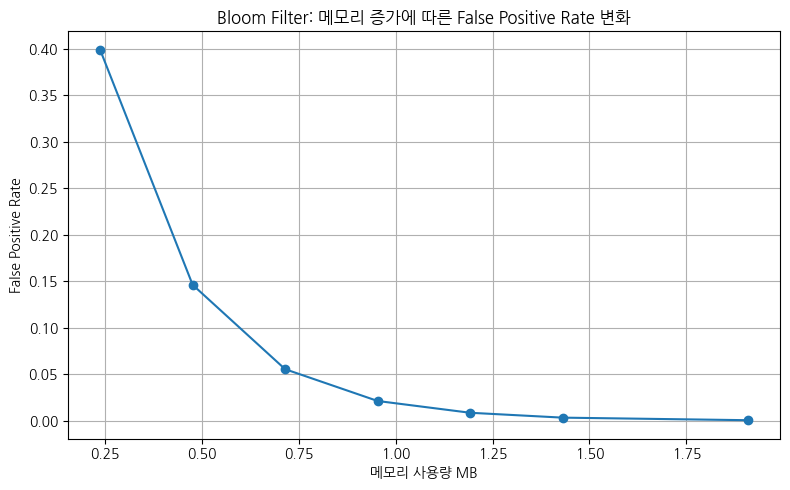

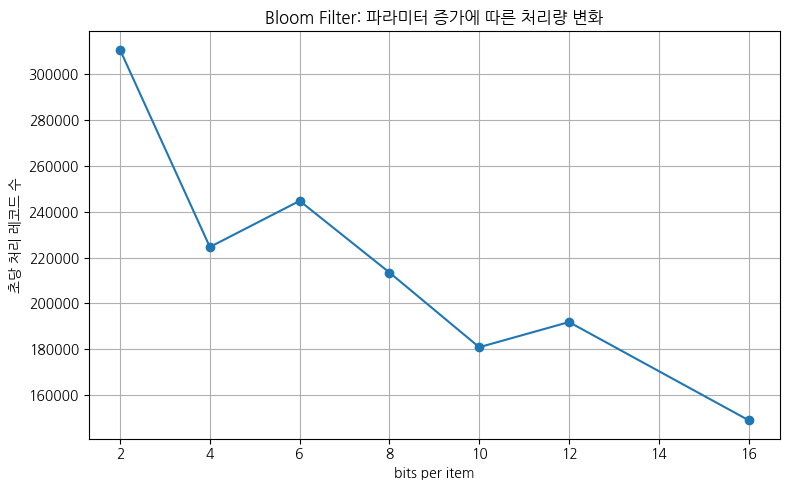

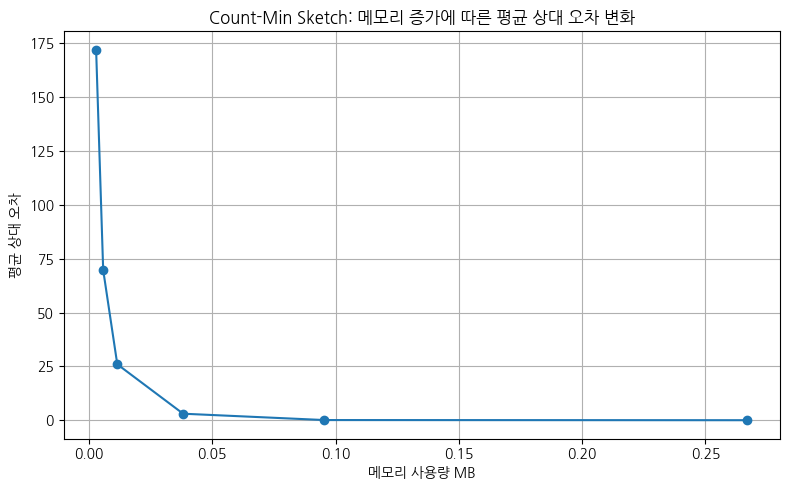

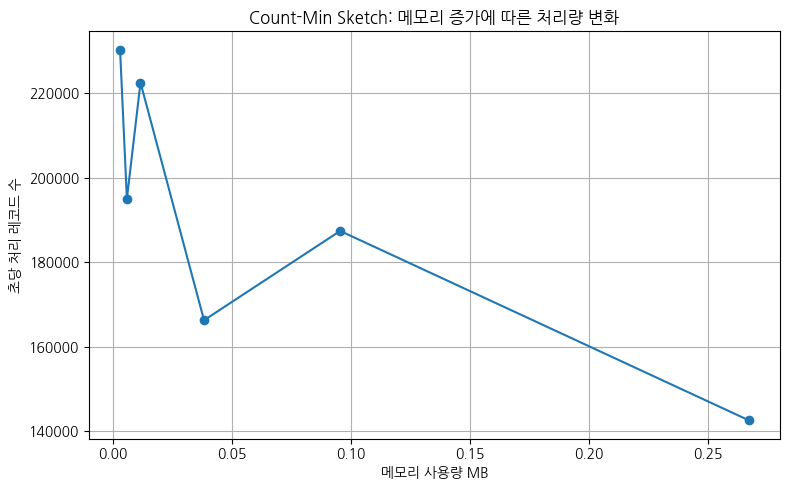

In [49]:
# Bloom Filter: 메모리 vs False Positive Rate
plt.figure(figsize=(8, 5))
plt.plot(bf_df["memory_mb"], bf_df["false_positive_rate"], marker="o")
plt.xlabel("메모리 사용량 MB")
plt.ylabel("False Positive Rate")
plt.title("Bloom Filter: 메모리 증가에 따른 False Positive Rate 변화")
plt.grid(True)
plt.tight_layout()

bf_fpr_plot = RESULT_DIR / "bloom_memory_fpr.png"
plt.savefig(bf_fpr_plot, dpi=200)
plt.show()


# Bloom Filter: bits per item vs 처리량
plt.figure(figsize=(8, 5))
plt.plot(bf_df["bits_per_item"], bf_df["throughput_records_per_sec"], marker="o")
plt.xlabel("bits per item")
plt.ylabel("초당 처리 레코드 수")
plt.title("Bloom Filter: 파라미터 증가에 따른 처리량 변화")
plt.grid(True)
plt.tight_layout()

bf_time_plot = RESULT_DIR / "bloom_throughput.png"
plt.savefig(bf_time_plot, dpi=200)
plt.show()


# Count-Min Sketch: 메모리 vs 평균 상대 오차
plt.figure(figsize=(8, 5))
plt.plot(cms_df["memory_mb"], cms_df["mean_relative_error"], marker="o")
plt.xlabel("메모리 사용량 MB")
plt.ylabel("평균 상대 오차")
plt.title("Count-Min Sketch: 메모리 증가에 따른 평균 상대 오차 변화")
plt.grid(True)
plt.tight_layout()

cms_error_plot = RESULT_DIR / "cms_memory_error.png"
plt.savefig(cms_error_plot, dpi=200)
plt.show()


# Count-Min Sketch: 메모리 vs 처리량
plt.figure(figsize=(8, 5))
plt.plot(cms_df["memory_mb"], cms_df["throughput_records_per_sec"], marker="o")
plt.xlabel("메모리 사용량 MB")
plt.ylabel("초당 처리 레코드 수")
plt.title("Count-Min Sketch: 메모리 증가에 따른 처리량 변화")
plt.grid(True)
plt.tight_layout()

cms_time_plot = RESULT_DIR / "cms_throughput.png"
plt.savefig(cms_time_plot, dpi=200)
plt.show()

In [50]:
best_bf = bf_df.loc[bf_df["false_positive_rate"].idxmin()]
fastest_bf = bf_df.loc[bf_df["throughput_records_per_sec"].idxmax()]

best_cms = cms_df.loc[cms_df["mean_relative_error"].idxmin()]
fastest_cms = cms_df.loc[cms_df["throughput_records_per_sec"].idxmax()]

env_info = {
    "python_version": sys.version.split()[0],
    "platform": platform.platform(),
    "cpu_count": os.cpu_count(),
    "ram_gb": round(psutil.virtual_memory().total / (1024 ** 3), 2) if psutil else "unknown"
}

analysis_text = f"""
본 실험에서는 MovieLens 1M의 평점 이벤트를 스트림으로 간주하고, 전체 데이터를 한 번에 메모리에 올리지 않는 방식으로 Bloom Filter와 Count-Min Sketch를 구현하였다.

Bloom Filter 실험 결과, bits per item이 증가할수록 bit array 크기가 증가하여 메모리 사용량은 증가했지만 False Positive Rate는 전반적으로 감소하였다. 가장 낮은 False Positive Rate는 bits_per_item={int(best_bf["bits_per_item"])} 설정에서 관찰되었으며, 이때 실제 FPR은 {best_bf["false_positive_rate"]:.6f}, 메모리 사용량은 {best_bf["memory_mb"]:.4f}MB였다.

Count-Min Sketch 실험 결과, width와 depth가 커질수록 충돌 가능성이 감소하여 평균 상대 오차가 전반적으로 감소하였다. 가장 낮은 평균 상대 오차는 width={int(best_cms["width"])}, depth={int(best_cms["depth"])} 설정에서 관찰되었으며, 평균 상대 오차는 {best_cms["mean_relative_error"]:.6f}, 메모리 사용량은 {best_cms["memory_mb"]:.4f}MB였다.

다만 파라미터 증가가 항상 좋은 결과만 가져온 것은 아니다. Bloom Filter에서는 hash 함수 개수가 증가하면 membership 검사와 삽입 연산마다 계산해야 할 hash 수가 늘어나 처리 시간이 증가할 수 있다. Count-Min Sketch에서도 depth가 증가하면 업데이트해야 할 row 수가 증가하므로 정확도는 개선될 수 있지만 처리량은 감소할 수 있다.

실제 서비스 로그 분석에서는 단순 포함 여부 확인보다 특정 URL, 상품, 사용자, 이벤트 타입의 빈도 추정이 더 자주 필요하다. 따라서 본 실험 조건에서는 Count-Min Sketch가 더 실용적이라고 판단된다. 다만 중복 이벤트 감지나 이미 본 사용자 여부 확인처럼 membership test가 핵심인 경우에는 Bloom Filter가 더 적합하다.
"""

print(analysis_text)


본 실험에서는 MovieLens 1M의 평점 이벤트를 스트림으로 간주하고, 전체 데이터를 한 번에 메모리에 올리지 않는 방식으로 Bloom Filter와 Count-Min Sketch를 구현하였다.

Bloom Filter 실험 결과, bits per item이 증가할수록 bit array 크기가 증가하여 메모리 사용량은 증가했지만 False Positive Rate는 전반적으로 감소하였다. 가장 낮은 False Positive Rate는 bits_per_item=16 설정에서 관찰되었으며, 이때 실제 FPR은 0.000420, 메모리 사용량은 1.9077MB였다.

Count-Min Sketch 실험 결과, width와 depth가 커질수록 충돌 가능성이 감소하여 평균 상대 오차가 전반적으로 감소하였다. 가장 낮은 평균 상대 오차는 width=10000, depth=7 설정에서 관찰되었으며, 평균 상대 오차는 0.001359, 메모리 사용량은 0.2670MB였다.

다만 파라미터 증가가 항상 좋은 결과만 가져온 것은 아니다. Bloom Filter에서는 hash 함수 개수가 증가하면 membership 검사와 삽입 연산마다 계산해야 할 hash 수가 늘어나 처리 시간이 증가할 수 있다. Count-Min Sketch에서도 depth가 증가하면 업데이트해야 할 row 수가 증가하므로 정확도는 개선될 수 있지만 처리량은 감소할 수 있다.

실제 서비스 로그 분석에서는 단순 포함 여부 확인보다 특정 URL, 상품, 사용자, 이벤트 타입의 빈도 추정이 더 자주 필요하다. 따라서 본 실험 조건에서는 Count-Min Sketch가 더 실용적이라고 판단된다. 다만 중복 이벤트 감지나 이미 본 사용자 여부 확인처럼 membership test가 핵심인 경우에는 Bloom Filter가 더 적합하다.



In [51]:
GITHUB_URL = "https://github.com/your-id/streaming-algorithms-report"  # 본인 GitHub 주소로 수정

def df_to_html_table(df, float_digits=6):
    return df.to_html(
        index=False,
        border=0,
        classes="result-table",
        float_format=lambda x: f"{x:.{float_digits}f}"
    )

bf_table_html = df_to_html_table(bf_df)
cms_table_html = df_to_html_table(cms_df)

html = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<title>스트리밍 알고리즘 실험 결과 보고서</title>
<style>
    body {{
        font-family: 'NanumGothic', sans-serif;
        line-height: 1.7;
        margin: 36px;
        color: #222;
    }}

    h1 {{
        text-align: center;
        border-bottom: 3px solid #222;
        padding-bottom: 16px;
    }}

    h2 {{
        margin-top: 36px;
        border-left: 6px solid #333;
        padding-left: 10px;
        background: #f4f4f4;
        padding-top: 6px;
        padding-bottom: 6px;
    }}

    h3 {{
        margin-top: 24px;
    }}

    table {{
        width: 100%;
        border-collapse: collapse;
        margin: 16px 0;
        font-size: 10px;
    }}

    th, td {{
        border: 1px solid #aaa;
        padding: 6px;
        text-align: center;
    }}

    th {{
        background: #e9e9e9;
    }}

    .summary-box {{
        border: 1px solid #999;
        background: #f8f8f8;
        padding: 14px;
        margin: 16px 0;
    }}

    .highlight {{
        font-weight: bold;
        background: #fff2cc;
        padding: 2px 4px;
    }}

    img {{
        max-width: 90%;
        display: block;
        margin: 16px auto;
        border: 1px solid #ccc;
    }}

    .small {{
        font-size: 11px;
        color: #555;
    }}

    code {{
        background: #eee;
        padding: 2px 4px;
        border-radius: 4px;
    }}
</style>
</head>

<body>

<h1>스트리밍 알고리즘 2종 구현 및 정확도·메모리 트레이드오프 분석</h1>

<h2>1. 데이터셋 설명</h2>

<p>
본 실험에서는 <b>MovieLens 1M</b> 데이터셋을 사용하였다.
해당 데이터셋의 평점 기록을 사용자 이벤트 스트림으로 간주하였다.
각 레코드는 <code>UserID::MovieID::Rating::Timestamp</code> 형식으로 구성되어 있으며,
본 실험에서는 전체 데이터를 한 번에 메모리에 올리지 않고 한 줄씩 읽는 스트리밍 방식으로 처리하였다.
</p>

<table>
<tr><th>항목</th><th>내용</th></tr>
<tr><td>데이터셋</td><td>MovieLens 1M</td></tr>
<tr><td>스트림 단위</td><td>사용자-영화 평점 이벤트</td></tr>
<tr><td>전체 레코드 수</td><td>{gt["total_records"]:,}</td></tr>
<tr><td>고유 이벤트 수</td><td>{gt["unique_events"]:,}</td></tr>
<tr><td>고유 영화 수</td><td>{gt["unique_movies"]:,}</td></tr>
<tr><td>파일 형식</td><td>DAT 텍스트 파일</td></tr>
</table>

<h2>2. 선택한 알고리즘 개요</h2>

<h3>2.1 Bloom Filter</h3>
<p>
Bloom Filter는 원소가 집합에 포함되어 있는지를 근사적으로 판정하는 확률적 자료구조이다.
여러 개의 hash 함수를 이용해 bit array의 위치를 1로 설정한다.
조회 시 해당 위치가 모두 1이면 포함되어 있다고 판단한다.
이때 실제로는 없는 원소를 있다고 판단하는 <b>false positive</b>가 발생할 수 있지만,
이미 삽입된 원소를 없다고 판단하는 <b>false negative</b>는 발생하지 않는다.
</p>

<h3>2.2 Count-Min Sketch</h3>
<p>
Count-Min Sketch는 데이터 스트림에서 항목별 빈도를 근사 추정하기 위한 자료구조이다.
여러 개의 hash 함수와 2차원 count table을 사용하며,
항목의 빈도 추정값은 각 row에서 얻은 count 값 중 최솟값으로 계산한다.
hash 충돌로 인해 실제 빈도보다 크게 추정될 수 있지만,
일반적으로 메모리를 크게 줄이면서 빈도 정보를 근사적으로 유지할 수 있다.
</p>

<h2>3. 구현 방식</h2>

<p>
두 알고리즘 모두 Python으로 직접 구현하였다.
Bloom Filter는 <code>bytearray</code> 기반 bit array를 사용하였고,
Count-Min Sketch는 <code>numpy</code> 배열 기반의 2차원 count table을 사용하였다.
hash 함수는 <code>hashlib.blake2b</code>를 이용해 deterministic hash를 생성하였다.
</p>

<table>
<tr><th>알고리즘</th><th>구현 방식</th><th>Ground Truth</th></tr>
<tr>
<td>Bloom Filter</td>
<td>bytearray 기반 bit array, double hashing</td>
<td>Python set 기반 실제 포함 여부</td>
</tr>
<tr>
<td>Count-Min Sketch</td>
<td>numpy 2차원 count table, double hashing</td>
<td>Python dictionary 기반 정확한 movie_id별 빈도</td>
</tr>
</table>

<p>
소스코드 GitHub 주소: <b>{GITHUB_URL}</b>
</p>

<h2>4. 실험 환경</h2>

<table>
<tr><th>항목</th><th>값</th></tr>
<tr><td>Python 버전</td><td>{env_info["python_version"]}</td></tr>
<tr><td>Platform</td><td>{env_info["platform"]}</td></tr>
<tr><td>CPU Core 수</td><td>{env_info["cpu_count"]}</td></tr>
<tr><td>RAM</td><td>{env_info["ram_gb"]} GB</td></tr>
</table>

<h2>5. 파라미터 설정</h2>

<h3>5.1 Bloom Filter</h3>
<p>
Bloom Filter는 <code>bits_per_item</code>을 변경하며 실험하였다.
전체 bit array 크기는 <code>전체 레코드 수 × bits_per_item</code>으로 설정하였다.
hash 함수 개수는 일반적인 최적값인 <code>k = (m / n) ln 2</code>에 근접하도록 설정하였다.
</p>

<h3>5.2 Count-Min Sketch</h3>
<p>
Count-Min Sketch는 <code>width</code>와 <code>depth</code>를 변경하며 실험하였다.
width가 증가하면 hash 충돌 가능성이 낮아지고,
depth가 증가하면 여러 row 중 최솟값을 사용하기 때문에 과대 추정 오차를 줄일 수 있다.
</p>

<h2>6. 정확도 비교 결과</h2>

<h3>6.1 Bloom Filter 결과</h3>
{bf_table_html}

<img src="{bf_fpr_plot}" alt="Bloom Filter FPR">

<p>
Bloom Filter는 메모리 사용량이 증가할수록 False Positive Rate가 전반적으로 감소하였다.
가장 낮은 False Positive Rate는
<span class="highlight">bits_per_item={int(best_bf["bits_per_item"])}</span>
설정에서 관찰되었으며,
실제 FPR은 <span class="highlight">{best_bf["false_positive_rate"]:.6f}</span>이었다.
</p>

<h3>6.2 Count-Min Sketch 결과</h3>
{cms_table_html}

<img src="{cms_error_plot}" alt="Count-Min Sketch Error">

<p>
Count-Min Sketch는 width와 depth가 증가할수록 평균 상대 오차가 전반적으로 감소하였다.
가장 낮은 평균 상대 오차는
<span class="highlight">width={int(best_cms["width"])}, depth={int(best_cms["depth"])}</span>
설정에서 관찰되었으며,
평균 상대 오차는 <span class="highlight">{best_cms["mean_relative_error"]:.6f}</span>이었다.
</p>

<h2>7. 메모리 사용량 비교 결과</h2>

<p>
Bloom Filter의 메모리 사용량은 bit array 크기에 의해 결정되며,
bits per item이 커질수록 선형적으로 증가하였다.
Count-Min Sketch의 메모리 사용량은 <code>width × depth × counter 크기</code>에 비례한다.
따라서 두 알고리즘 모두 정확도 향상을 위해서는 더 큰 메모리 사용량이 필요했다.
</p>

<h2>8. 처리 시간 비교 결과</h2>

<img src="{bf_time_plot}" alt="Bloom Filter Throughput">
<img src="{cms_time_plot}" alt="Count-Min Sketch Throughput">

<p>
처리 시간은 hash 계산 횟수와 자료구조 업데이트 횟수에 영향을 받았다.
Bloom Filter는 hash 함수 개수가 증가할수록 삽입과 조회 비용이 증가할 수 있다.
Count-Min Sketch는 depth가 증가할수록 각 이벤트마다 업데이트해야 하는 row 수가 증가하므로
처리량이 감소할 수 있다.
</p>

<h2>9. 알고리즘별 장단점 분석</h2>

<table>
<tr><th>알고리즘</th><th>장점</th><th>단점</th><th>적합한 상황</th></tr>
<tr>
<td>Bloom Filter</td>
<td>매우 적은 메모리로 membership test 가능, false negative 없음</td>
<td>false positive 발생, 삭제 어려움, 빈도 추정 불가</td>
<td>중복 검사, 이미 본 사용자/URL/이벤트 확인</td>
</tr>
<tr>
<td>Count-Min Sketch</td>
<td>대용량 스트림에서 항목별 빈도 추정 가능, 메모리 효율적</td>
<td>hash 충돌로 인한 과대 추정 가능, 정확한 값은 아님</td>
<td>인기 상품, 인기 URL, hot key, 이벤트 빈도 분석</td>
</tr>
</table>

<h2>10. 최종 분석 질문</h2>

<div class="summary-box">
<p><b>Q1. 정확도와 메모리 사이에는 어떤 trade-off가 있었는가?</b></p>
<p>
Bloom Filter에서는 bit array 크기가 커질수록 false positive가 감소했지만 메모리 사용량이 증가하였다.
Count-Min Sketch에서는 width와 depth가 커질수록 hash 충돌이 줄어 빈도 추정 오차가 감소했지만,
그만큼 count table 크기가 커져 메모리 사용량이 증가하였다.
즉, 두 알고리즘 모두 정확도를 높이려면 더 많은 메모리를 사용해야 하는 trade-off가 있었다.
</p>

<p><b>Q2. 파라미터 증가가 항상 성능 향상으로 이어졌는가?</b></p>
<p>
항상 그렇지는 않았다.
파라미터 증가는 정확도 측면에서는 대체로 유리했지만,
처리 시간 측면에서는 불리할 수 있었다.
Bloom Filter에서 hash 함수 개수가 많아지면 삽입과 조회 시 hash 계산 비용이 증가한다.
Count-Min Sketch에서도 depth가 커지면 각 레코드마다 여러 row를 업데이트해야 하므로 처리량이 감소할 수 있다.
따라서 파라미터 증가는 정확도 개선과 시간 비용 증가 사이의 균형으로 해석해야 한다.
</p>

<p><b>Q3. 어떤 알고리즘이 가장 실용적이라고 판단되는가?</b></p>
<p>
본 실험에서는 Count-Min Sketch가 더 실용적이라고 판단된다.
실제 로그 분석에서는 특정 이벤트, URL, 상품, 사용자 행동의 발생 빈도를 파악하는 경우가 많기 때문이다.
Count-Min Sketch는 전체 데이터를 저장하지 않고도 항목별 빈도를 근사 추정할 수 있어,
대용량 서비스 로그 분석에 적합하다.
</p>

<p><b>Q4. 실제 서비스 로그 분석에 적용한다면 어떤 알고리즘을 선택할 것인가?</b></p>
<p>
실제 서비스 로그 분석에서는 Count-Min Sketch를 선택할 것이다.
예를 들어 인기 페이지, 많이 클릭된 상품, 비정상적으로 많이 발생하는 에러 코드,
hot key 탐지 등은 모두 빈도 추정 문제로 볼 수 있다.
Count-Min Sketch는 제한된 메모리 안에서 이러한 빈도 정보를 빠르게 추정할 수 있으므로
실시간 로그 모니터링이나 대시보드 시스템에 적용하기 적합하다.
다만 중복 이벤트 제거 또는 이미 처리된 요청 여부 확인이 목적이라면 Bloom Filter를 함께 사용할 수 있다.
</p>
</div>

<h2>11. 결론</h2>

<p>
본 과제에서는 MovieLens 1M 데이터셋을 스트리밍 방식으로 처리하며
Bloom Filter와 Count-Min Sketch를 직접 구현하고 비교하였다.
Bloom Filter는 membership test에 매우 효율적이며,
Count-Min Sketch는 빈도 추정에 적합하였다.
실험 결과, 두 알고리즘 모두 메모리를 더 많이 사용할수록 정확도는 개선되었지만,
파라미터 증가로 인해 처리 시간이 늘어날 수 있음을 확인하였다.
따라서 스트리밍 알고리즘을 실제 서비스에 적용할 때는
정확도, 메모리, 처리량 사이의 균형을 고려해 파라미터를 설정해야 한다.
</p>

</body>
</html>
"""

html_path = RESULT_DIR / "streaming_algorithm_report.html"

with open(html_path, "w", encoding="utf-8") as f:
    f.write(html)

print("HTML 보고서 생성 완료:", html_path)

HTML 보고서 생성 완료: /content/results/streaming_algorithm_report.html


In [52]:
from pathlib import Path
import subprocess

RESULT_DIR = Path("/content/results")
html_path = RESULT_DIR / "streaming_algorithm_report.html"
pdf_path = RESULT_DIR / "streaming_algorithm_report.pdf"

cmd = [
    "wkhtmltopdf",
    "--enable-local-file-access",
    "--encoding", "utf-8",
    str(html_path),
    str(pdf_path)
]

subprocess.run(cmd, check=True)

print("PDF 보고서 생성 완료:", pdf_path)

PDF 보고서 생성 완료: /content/results/streaming_algorithm_report.pdf


In [53]:
from google.colab import files

files.download(str(pdf_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>